Looping through images

In [22]:
import numpy as np
from PIL import Image, ImageEnhance, ImageFilter
from scipy.ndimage import convolve

def gaussian_blur(image, mean=0, sigma=15):
    np_image = np.array(image).astype(np.float32)

    noise = np.random.normal(mean, sigma, np_image.shape)

    noise_arr = np.clip(np_image + noise, 0, 255).astype(np.uint8)

    return Image.fromarray(noise_arr)

def motion_blur(image, kernel_size=15):
    np_image = np.array(image)

    kernel = np.zeros((kernel_size, kernel_size))
    kernel[int((kernel_size-1)/2), :] = np.ones(kernel_size)
    kernel /= kernel_size

    blurred = []
    for i in range(np_image.shape[2]):
        blur_chan = convolve(np_image[:, :, i], kernel)
        blurred.append(blur_chan)

    blurred_arr = np.stack(blurred, axis=2).astype(np.uint8)

    return Image.fromarray(blurred_arr)

def defocus_blur(img, radius=3):
    return img.filter(ImageFilter.GaussianBlur(radius=radius))

def jitter(img, brightness=1.0, contrast=1.0):
    enhancer = ImageEnhance.Brightness(img)
    img = enhancer.enhance(brightness)

    enhancer = ImageEnhance.Contrast(img)
    img = enhancer.enhance(contrast)

    return img
    


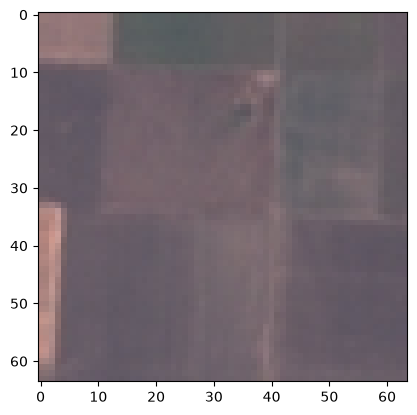

In [45]:
import os
from os import listdir
from PIL import Image
import matplotlib.pyplot as plt

p = "D:/Projects/synapse/spacecraft-neuromorphic-architecture/src/data/test_images_distorted"
ok = 0

for image_class in os.listdir(p):
    if ok == 1:
        break

    class_path = os.path.join(p, image_class)

    if not os.path.isdir(class_path):
        continue

    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)

        try:
            with Image.open(image_path) as img:
                original = img.convert("RGB")

                noise_img = gaussian_blur(original, sigma=5)
                blurred_img = motion_blur(original, kernel_size=10)
                defocused_img = defocus_blur(original, radius=1)
                jittered_img = jitter(original, brightness=1.0, contrast=1.0)

                plt.imshow(jittered_img)
                plt.axis('on')
                plt.show()
                
                ok = 1
                break
        except Exception as e:
            print(f"Could not process {image_name}: {e}")
